# Medidas de heterogeneidad

Práctica 4 · ENDIREH 2021

**Estado:** configuración inicial; análisis pendiente.

**Objetivo para la siguiente etapa:** Calcular IQV, Gini-Simpson y entropía de Shannon sobre variables categóricas.

La entrada es el CSV renombrado, generado desde el archivo limpio de la Práctica 3 en `ajuste_columnas_practica_4.ipynb`. Por ahora solo se preparan imports, carga y revisión de columnas.


## 1. Configuración del proyecto

Selecciona el entorno Python `endireh` antes de ejecutar las celdas.


In [1]:
from pathlib import Path
import sys

# Funciona si Jupyter se inicia en la raíz o dentro de notebooks/.
RUTA_PROYECTO = next(
    (ruta for ruta in (Path.cwd(), *Path.cwd().parents)
     if (ruta / "config" / "rutas.py").is_file()),
    None,
)
if RUTA_PROYECTO is None:
    raise FileNotFoundError(
        "No se encontró config/rutas.py. Abre el notebook dentro del proyecto."
    )
if str(RUTA_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RUTA_PROYECTO))


In [2]:
import polars as pl
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from config.rutas import RUTA_ENDIREH_RENOMBRADO_CSV

sns.set_theme(style="whitegrid")
pl.Config.set_tbl_rows(100)


polars.config.Config

## 2. Carga del dataset procesado

Se conserva el CSV original. La validación de columnas no garantiza que los datos estén listos para todos los cálculos.


In [3]:
if not RUTA_ENDIREH_RENOMBRADO_CSV.is_file():
    raise FileNotFoundError(
        f"No se encontró el CSV procesado: {RUTA_ENDIREH_RENOMBRADO_CSV}. "
        "Ejecuta primero notebooks/ajuste_columnas_practica_4.ipynb."
    )

df = pl.read_csv(RUTA_ENDIREH_RENOMBRADO_CSV)

# Solo se valida la estructura básica; no se limpian ni transforman datos.
columnas_requeridas = {
    "cve_entidad", "nom_entidad", "sufrio_violencia_pareja", "factor_expansion"
}
columnas_faltantes = columnas_requeridas.difference(df.columns)
if columnas_faltantes:
    raise ValueError(f"Faltan columnas requeridas: {sorted(columnas_faltantes)}")

print(f"Archivo: {RUTA_ENDIREH_RENOMBRADO_CSV.name}")
print(f"Filas: {df.height:,} | Columnas: {df.width}")
df.head(5)


Archivo: endireh_2021_renombrado.csv
Filas: 110,127 | Columnas: 24


cve_entidad,nom_entidad,cve_municipio,nom_municipio,anios_sin_convivencia_pareja,tipo_union,tipo_cuestionario,estado_civil_id,estado_civil_desc,estrato_sociodemografico_muestreo,entrevistada_trabaja_id,entrevistada_trabaja_desc,ingreso_laboral_entrevistada,dinero_propio_id,dinero_propio_desc,apoyo_gobierno_id,apoyo_gobierno_desc,hogar_tiene_ahorros_id,hogar_tiene_ahorros_desc,vivienda_propiedad_miembro_hogar_id,vivienda_propiedad_miembro_hogar_desc,sufrio_violencia_pareja,factor_expansion,anio_encuesta
i64,str,i64,str,i64,i64,str,i64,str,i64,i64,str,f64,i64,str,i64,str,i64,str,i64,str,i64,i64,i64
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,3,"""A1""",5,"""Casada""",4,1,"""Sí""",10000.0,1,"""Sí""",2,"""No""",2,"""No""",1,"""Sí""",0,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,3,"""A1""",5,"""Casada""",4,2,"""No""",null,2,"""No""",1,"""Sí""",2,"""No""",1,"""Sí""",1,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",13,3,"""B2""",4,"""Viuda""",4,2,"""No""",null,2,"""No""",1,"""Sí""",2,"""No""",2,"""No""",0,227,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,null,"""C1""",6,"""Soltera""",4,1,"""Sí""",8500.0,1,"""Sí""",2,"""No""",1,"""Sí""",1,"""Sí""",0,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",20,3,"""B1""",2,"""Separada""",2,1,"""Sí""",400.0,1,"""Sí""",2,"""No""",2,"""No""",1,"""Sí""",1,155,2021


## 3. Variables 

Se seleccionaron variables cualitativas relacionadas con características sociales y económicas de las mujeres encuestadas: estado civil, disponibilidad de dinero propio, recepción de apoyo gubernamental y presencia de ahorros en el hogar. Sobre estas variables se analizará qué tan equilibrada o concentrada se encuentra la distribución de sus categorías.
 y documentar el uso del factor de expansión.

Se consultaron las correspondencias y las decisiones heredadas en `ajuste_columnas_practica_4.ipynb` antes de elegir variables.


In [4]:
variables_cualitativas = [
    "estado_civil_desc",
    "dinero_propio_desc",
    "apoyo_gobierno_desc",
    "hogar_tiene_ahorros_desc"
]
tablas_frecuencia = {}

for variable in variables_cualitativas:

    frecuencias = (
        df
        .group_by(variable)
        .len()
        .rename({"len": "frecuencia"})
        .with_columns(
            (
                pl.col("frecuencia")
                / pl.col("frecuencia").sum()
            ).alias("pi")
        )
        .sort("frecuencia", descending=True)
    )

    tablas_frecuencia[variable] = frecuencias

    print(f"\n--- {variable} ---")
    print(frecuencias)


--- estado_civil_desc ---
shape: (6, 3)
┌───────────────────┬────────────┬──────────┐
│ estado_civil_desc ┆ frecuencia ┆ pi       │
│ ---               ┆ ---        ┆ ---      │
│ str               ┆ u32        ┆ f64      │
╞═══════════════════╪════════════╪══════════╡
│ Casada            ┆ 44977      ┆ 0.40841  │
│ Unión libre       ┆ 23597      ┆ 0.214271 │
│ Soltera           ┆ 20002      ┆ 0.181627 │
│ Viuda             ┆ 9750       ┆ 0.088534 │
│ Separada          ┆ 8628       ┆ 0.078346 │
│ Divorciada        ┆ 3173       ┆ 0.028812 │
└───────────────────┴────────────┴──────────┘

--- dinero_propio_desc ---
shape: (2, 3)
┌────────────────────┬────────────┬──────────┐
│ dinero_propio_desc ┆ frecuencia ┆ pi       │
│ ---                ┆ ---        ┆ ---      │
│ str                ┆ u32        ┆ f64      │
╞════════════════════╪════════════╪══════════╡
│ Sí                 ┆ 57662      ┆ 0.523595 │
│ No                 ┆ 52465      ┆ 0.476405 │
└────────────────────┴────────────┴─

## 4. Cálculos

Se realizaron funciones reutilizables en `src/statistics/` para que puedan ser utilizadas ahi


In [5]:
from src.statistics.heterogeneidad import (
    gini_simpson,
    iqv,
    entropia_shannon,
)

In [6]:
resultados_heterogeneidad = []
tablas_frecuencia = {}

for variable in variables_cualitativas:

    # Tabla de frecuencias y proporciones pi
    frecuencias = (
        df
        .group_by(variable)
        .len()
        .rename({"len": "frecuencia"})
        .with_columns(
            (
                pl.col("frecuencia")
                / pl.col("frecuencia").sum()
            ).alias("pi")
        )
        .sort("frecuencia", descending=True)
    )

    # Guardamos la tabla por si se necesita después
    tablas_frecuencia[variable] = frecuencias

    # Extraemos los pi de la variable
    pi = frecuencias["pi"].to_list()

    # Mandamos llamar las funciones de heterogeneidad.py
    resultado = {
        "variable": variable,
        "categorias": len(pi),
        "gini_simpson": gini_simpson(pi),
        "iqv": iqv(pi),
        "entropia_shannon": entropia_shannon(pi),
    }

    resultados_heterogeneidad.append(resultado)

In [8]:
#Impresiones de la heterogeneidad
tabla_heterogeneidad = (
    pl.DataFrame(resultados_heterogeneidad)
    .with_columns(
        pl.col("gini_simpson").round(4),
        pl.col("iqv").round(4),
        pl.col("entropia_shannon").round(4),
    )
)

tabla_heterogeneidad

variable,categorias,gini_simpson,iqv,entropia_shannon
str,i64,f64,f64,f64
"""estado_civil_desc""",6,0.7395,0.8874,2.1958
"""dinero_propio_desc""",2,0.4989,0.9978,0.9984
"""apoyo_gobierno_desc""",2,0.2376,0.4752,0.5784
"""hogar_tiene_ahorros_desc""",2,0.1933,0.3867,0.4951


## 5. Tablas y visualizaciones

A continuación se presentan las distribuciones de las variables cualitativas
seleccionadas, junto con sus frecuencias, proporciones y representaciones
gráficas.

Las gráficas permiten observar visualmente qué tan equilibradas o concentradas
se encuentran las categorías de cada variable, complementando los valores
obtenidos mediante Gini-Simpson, IQV y entropía de Shannon.


--- estado_civil_desc ---


estado_civil_desc,frecuencia,pi,porcentaje
str,u32,f64,f64
"""Casada""",44977,0.40841,40.84
"""Unión libre""",23597,0.214271,21.43
"""Soltera""",20002,0.181627,18.16
"""Viuda""",9750,0.088534,8.85
"""Separada""",8628,0.078346,7.83
"""Divorciada""",3173,0.028812,2.88


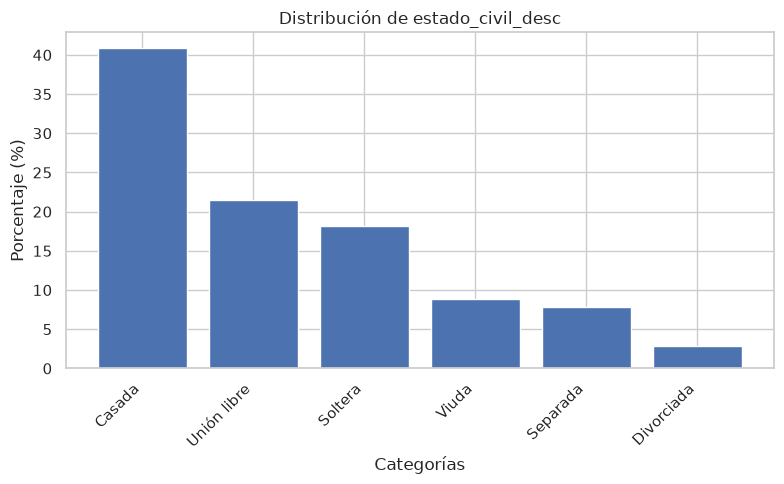


--- dinero_propio_desc ---


dinero_propio_desc,frecuencia,pi,porcentaje
str,u32,f64,f64
"""Sí""",57662,0.523595,52.36
"""No""",52465,0.476405,47.64


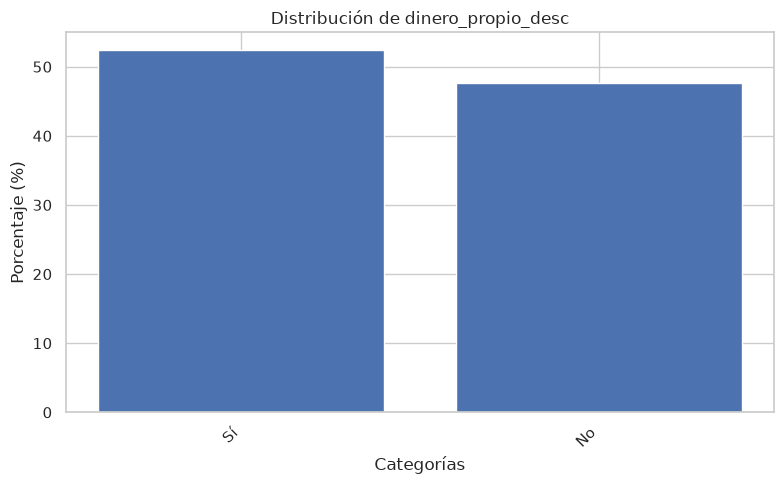


--- apoyo_gobierno_desc ---


apoyo_gobierno_desc,frecuencia,pi,porcentaje
str,u32,f64,f64
"""No""",94953,0.862214,86.22
"""Sí""",15174,0.137786,13.78


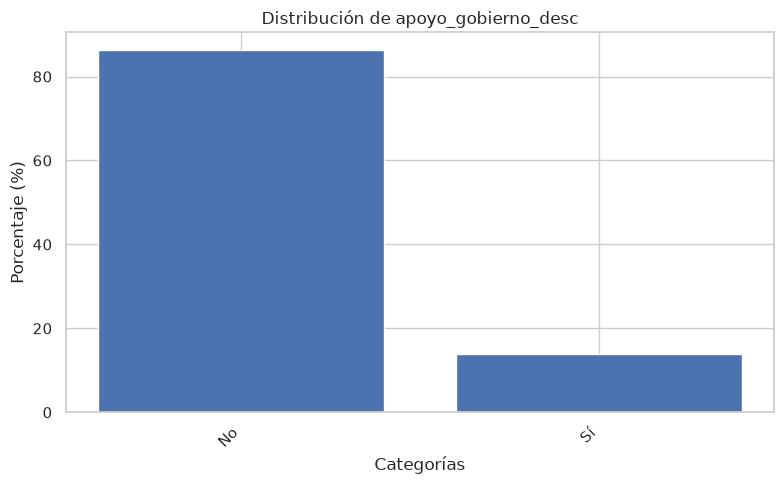


--- hogar_tiene_ahorros_desc ---


hogar_tiene_ahorros_desc,frecuencia,pi,porcentaje
str,u32,f64,f64
"""No""",98187,0.89158,89.16
"""Sí""",11940,0.10842,10.84


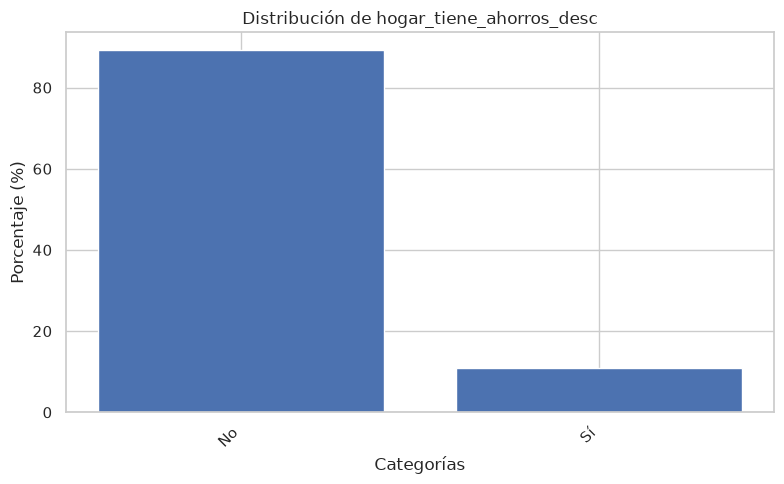

In [9]:
import matplotlib.pyplot as plt


for variable in variables_cualitativas:

    # Recuperamos la tabla que ya calculamos anteriormente
    tabla = (
        tablas_frecuencia[variable]
        .with_columns(
            (pl.col("pi") * 100)
            .round(2)
            .alias("porcentaje")
        )
    )

    print(f"\n--- {variable} ---")

    display(tabla)

    # Datos para la gráfica
    categorias = tabla[variable].cast(pl.String).to_list()
    porcentajes = tabla["porcentaje"].to_list()

    # Gráfica
    plt.figure(figsize=(8, 5))

    plt.bar(categorias, porcentajes)

    plt.title(f"Distribución de {variable}")
    plt.xlabel("Categorías")
    plt.ylabel("Porcentaje (%)")

    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

## 6. Interpretación y limitaciones

A partir de los valores obtenidos mediante el índice de Gini-Simpson, el Índice de Variación Cualitativa (IQV) y la entropía de Shannon, se puede analizar qué tan equilibradas o concentradas se encuentran las categorías de cada una de las variables cualitativas seleccionadas.

### `dinero_propio_desc`

La variable `dinero_propio_desc` presenta una **heterogeneidad muy alta**. El índice de Gini-Simpson es aproximadamente **0.499**, el IQV es cercano a **0.998** y la entropía de Shannon es aproximadamente **0.998**, muy próxima a su máximo posible de **1** para una variable con dos categorías.

Esto se debe a que las categorías `"Sí"` y `"No"` se encuentran casi equilibradas, representando aproximadamente el **52 %** y **48 %** de las observaciones, respectivamente. Por lo tanto, ninguna de las dos categorías domina claramente la distribución.

### `apoyo_gobierno_desc`

La variable `apoyo_gobierno_desc` presenta una **heterogeneidad moderada-baja**. El índice de Gini-Simpson es aproximadamente **0.238**, el IQV es cercano a **0.475** y la entropía de Shannon es aproximadamente **0.578**.

En esta variable existe un claro predominio de una de las categorías. Aproximadamente el **86 %** de las observaciones corresponden a personas que no reciben apoyo del gobierno, mientras que alrededor del **14 %** sí lo recibe. Este desequilibrio provoca que los índices de heterogeneidad sean menores.

### `hogar_tiene_ahorros_desc`

La variable `hogar_tiene_ahorros_desc` presenta una **heterogeneidad baja en comparación con las demás variables binarias analizadas**. El índice de Gini-Simpson es aproximadamente **0.193**, el IQV es cercano a **0.387** y la entropía de Shannon es aproximadamente **0.495**.

Esto se explica porque cerca del **89 %** de las observaciones se concentran en una sola categoría, mientras que alrededor del **11 %** pertenece a la categoría restante. Al existir una categoría claramente dominante, la distribución es menos diversa.

### `estado_civil_desc`

La variable `estado_civil_desc` presenta una **heterogeneidad alta**, ya que las observaciones se encuentran distribuidas entre sus **seis categorías** y no concentradas exclusivamente en una de ellas.

La entropía de Shannon obtenida es aproximadamente **2.19**. Debido a que esta variable contiene seis categorías, su entropía máxima posible es:

$$
H_{max} = \log_2(6) \approx 2.5849
$$

El valor obtenido se encuentra relativamente cerca de este máximo, lo que indica una diversidad considerable entre las categorías de estado civil.

Los valores de Gini-Simpson e IQV también indican una heterogeneidad elevada. Sin embargo, esta no es máxima debido a que las seis categorías no presentan exactamente la misma frecuencia y algunas concentran una mayor cantidad de observaciones que otras.

### Interpretación general

En conjunto, `dinero_propio_desc` presenta la **mayor heterogeneidad entre las variables binarias**, debido a que sus dos categorías se encuentran prácticamente equilibradas. `estado_civil_desc` también presenta una heterogeneidad elevada, ya que sus observaciones se distribuyen entre varias categorías.

Por otro lado, `apoyo_gobierno_desc` presenta una heterogeneidad menor debido al predominio de una de sus categorías, mientras que `hogar_tiene_ahorros_desc` presenta la **menor heterogeneidad** de las variables analizadas, al concentrar la mayoría de las observaciones en una sola categoría.

En general, se observa que una distribución más equilibrada entre las categorías produce valores mayores de Gini-Simpson, IQV y entropía de Shannon, mientras que el predominio de una categoría provoca que estos índices disminuyan.

### Limitaciones

Estas medidas permiten conocer qué tan diversas o equilibradas son las categorías de una variable, pero **no permiten determinar por sí solas relaciones de causa y efecto ni explicar por qué se presenta determinada distribución**.

Además, los valores de entropía de Shannon dependen del número de categorías disponibles, por lo que no siempre es adecuado comparar directamente su valor absoluto entre variables con diferente cantidad de categorías sin considerar su entropía máxima.

Otra limitación es que las medidas describen la distribución de las categorías en los datos analizados, pero no indican si existe una relación estadística entre estas variables y otras características del fenómeno estudiado. Por ejemplo, una alta o baja heterogeneidad en `dinero_propio_desc` no implica por sí misma una relación directa con la presencia de violencia.

Finalmente, la interpretación de los resultados depende de la forma en que fueron definidas y codificadas las categorías de cada variable, por lo que los índices deben analizarse junto con las tablas de frecuencias, proporciones y el contexto de la información.